# 05: Advanced Spillover Models

This notebook adds machine learning to the interference workflow.

The previous notebooks established the causal design and estimated direct, indirect, and total effects with transparent randomized estimators. That is the foundation. This notebook asks a more advanced product question:

> Can we use user, item, slate, and spillover features to predict when a promotion is likely to create positive net slate value?

The notebook uses advanced models for three purposes:

1. **Outcome modeling**: predict total simulated slate clicks from pre-promotion features and treatment assignment.
2. **Conditional effect modeling**: predict the counterfactual difference between promoting the focal item and leaving it unpromoted.
3. **Policy targeting**: compare random promotion with model-targeted promotion rules.

The important discipline is that ML supports the causal design. Treatment was randomized at the slate level, so the simple randomized estimator remains the baseline. The models are used to understand heterogeneity and policy targeting, and their predictions are checked against the known simulation lift available in this synthetic setup.


<!-- dataset-experiment-context -->
## Dataset and Simulation Design Context

This project uses MovieLens 32M as a realistic user-item preference source. MovieLens contains ratings and movie metadata, but it lacks production recommendation impressions, randomized promotions, and observed slate outcomes.

Because the public data lack a real experiment, the project builds a transparent simulation. It constructs recommendation slates, selects lower-ranked focal movies, randomizes focal promotion at the slate level, and generates outcomes through an explicit competition model.

The simulated experiment is designed to teach interference. Promoting one item can increase that item's engagement while reducing attention for substitutes and neighboring items. The estimands are direct focal effects, spillover effects, and total slate value, so the project emphasizes experiment design and measurement logic as a teaching workflow.

**Role of this notebook.** This notebook adds flexible outcome models and targeted policy evaluation to ask whether model-assisted targeting can avoid harmful promotions.

<!-- mathematical-setup -->

## Mathematical Setup

Model-assisted interference analysis predicts counterfactual outcomes under alternative exposure states. If \(X_i\) contains slate and item features, the outcome model is

$$
\mu(d,s,X_i)=\mathbb{E}[Y_i\mid D_i=d,S_i=s,X_i].
$$

A counterfactual direct-effect estimate averages predicted differences:

$$
\widehat\tau_{\text{direct}}=\frac{1}{n}\sum_i
\left\{\widehat\mu(1,S_i,X_i)-\widehat\mu(0,S_i,X_i)\right\}.
$$

The machine-learning models are therefore used for adjustment, heterogeneity, and prediction. Their estimates still need to be checked against the known simulation structure and simpler randomized estimators.


#### 1. Environment and Paths

This cell imports the modeling libraries. LightGBM and XGBoost are used as flexible tree-based outcome models, while scikit-learn provides splitting, metrics, and cross-fitting utilities. The path logic searches upward for the processed interference files so the notebook works from JupyterLab or command-line execution.


In [1]:
# Set up environment and paths.
from pathlib import Path
import re
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "movielens_interference_exposure_mapping.parquet").exists()
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"

EXPOSURE_PATH = PROCESSED_DIR / "movielens_interference_exposure_mapping.parquet"
COMPONENT_SLATE_PATH = PROCESSED_DIR / "movielens_interference_component_slate.parquet"
OBSERVED_EFFECTS_PATH = PROCESSED_DIR / "movielens_interference_observed_effects.csv"
PRODUCT_SUMMARY_PATH = PROCESSED_DIR / "movielens_interference_product_summary.csv"

EXPOSURE_PATH.exists(), COMPONENT_SLATE_PATH.exists(), OBSERVED_EFFECTS_PATH.exists(), PRODUCT_SUMMARY_PATH.exists()


(True, True, True, True)

All checks should return `True`. The advanced notebook builds on the exposure mapping, component slate table, prior randomized estimates, and product-unit decomposition created earlier. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


#### 2. Load Prior Outputs

This cell loads the item-row exposure table and the slate-level component table. The item-row table is used to construct pre-promotion slate features and reconstruct the known simulation lift. The slate-level table is used as the modeling unit because promotion was randomized at the slate level.


In [2]:
exposure = pd.read_parquet(EXPOSURE_PATH)
component_slate = pd.read_parquet(COMPONENT_SLATE_PATH)
observed_effects = pd.read_csv(OBSERVED_EFFECTS_PATH)
product_summary = pd.read_csv(PRODUCT_SUMMARY_PATH)

load_summary = pd.DataFrame(
    {
        "table": ["item_row_exposure", "component_slate", "observed_effects", "product_summary"],
        "rows": [len(exposure), len(component_slate), len(observed_effects), len(product_summary)],
        "unique_slates": [exposure["slate_id"].nunique(), component_slate["slate_id"].nunique(), np.nan, np.nan],
    }
)

display(load_summary)
display(product_summary)


,table,rows,unique_slates
0,item_row_exposure,36000,"3,000.0000"
1,component_slate,3000,"3,000.0000"
2,observed_effects,5,NaN
3,product_summary,5,NaN


,metric,value,plain_language
0,"Focal gain per 1,000 promoted slates",171.6152,Additional simulated clicks on the promoted fo...
1,"Same-cluster competitor change per 1,000 promo...",-145.3905,Change among substitute movies in the same gen...
2,"Other competitor change per 1,000 promoted slates",-334.0459,Change among other non-focal movies in the slate.
3,"Total slate change per 1,000 promoted slates",-307.8212,Net change after adding focal and competitor c...
4,Competitor offset as share of direct gain magn...,-2.7937,Negative values mean competitor losses more th...


The product summary reminds us why advanced models are worth adding. The direct focal gain was positive, and competitor losses more than offset it. The advanced models will look for segments where that net effect is less negative or potentially positive.


#### 3. Reconstruct the Known Counterfactual Promotion Lift

Because this is a simulation, we can reconstruct the expected outcome if every slate's focal item were promoted. Real observational data would lack this oracle signal. Here it is useful for validating model predictions.

This cell rebuilds the same outcome mechanism used in the exposure-mapping notebook. It computes:

- expected click probability under no promotion,
- expected click probability if the focal item is promoted,
- true expected net lift from promotion for every slate.

This gives us a benchmark for evaluating conditional-effect models and targeted promotion rules.


In [3]:
# Reconstruct the known counterfactual promotion lift.
def sigmoid(values):
    """
    Apply the logistic sigmoid transformation.
    
    Idea
    ----
    The simulation uses this helper to convert latent utility or score values into probabilities for generated recommendation outcomes.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    numpy.ndarray
        Values transformed to the interval from zero to one.
    """
    return 1 / (1 + np.exp(-values))

oracle_rows = exposure.copy()
non_focal = oracle_rows["is_focal_item"].eq(0)
same_cluster = oracle_rows["spillover_cluster"].eq(oracle_rows["focal_spillover_cluster"])
would_be_displaced = non_focal & oracle_rows["slate_position_seed"].lt(oracle_rows["focal_seed_position"])

oracle_rows["final_position_if_promoted"] = oracle_rows["slate_position_seed"]
oracle_rows.loc[oracle_rows["is_focal_item"].eq(1), "final_position_if_promoted"] = 1
oracle_rows.loc[would_be_displaced, "final_position_if_promoted"] = oracle_rows.loc[would_be_displaced, "slate_position_seed"] + 1
oracle_rows["visibility_if_promoted"] = 1 / np.log2(oracle_rows["final_position_if_promoted"] + 1)

liked_rate_mean = oracle_rows["liked_rate"].mean()
item_liked_rate_mean = oracle_rows["sample_liked_rate"].mean()
sample_liked_rate_filled = oracle_rows["sample_liked_rate"].fillna(item_liked_rate_mean)
log_item_popularity_z_filled = oracle_rows["log_item_popularity_z"].fillna(0)

promoted_logit = (
    -2.75
    + 0.78 * (oracle_rows["observed_relevance"] - 3.5)
    + 1.15 * oracle_rows["visibility_if_promoted"]
    + 0.35 * (oracle_rows["liked_rate"] - liked_rate_mean)
    + 0.25 * (sample_liked_rate_filled - item_liked_rate_mean)
    + 0.10 * log_item_popularity_z_filled
    + 0.20 * oracle_rows["is_focal_item"]
    - 0.08 * non_focal.astype(float)
    - 0.24 * (non_focal & same_cluster).astype(float)
    - 0.10 * would_be_displaced.astype(float)
)

oracle_rows["p_if_control"] = oracle_rows["p_no_promotion"]
oracle_rows["p_if_promoted"] = sigmoid(promoted_logit).clip(0.01, 0.95)
oracle_rows["true_item_lift_if_promoted"] = oracle_rows["p_if_promoted"] - oracle_rows["p_if_control"]

oracle_slate_lift = (
    oracle_rows.groupby("slate_id")
    .agg(
        true_promote_lift=("true_item_lift_if_promoted", "sum"),
        true_promote_expected_clicks=("p_if_promoted", "sum"),
        true_control_expected_clicks=("p_if_control", "sum"),
    )
    .reset_index()
)

promoted_validation = component_slate[["slate_id", "promotion_applied", "total_known_probability_lift"]].merge(
    oracle_slate_lift,
    on="slate_id",
    how="left",
)
promoted_validation["lift_difference_on_promoted_slates"] = np.where(
    promoted_validation["promotion_applied"].eq(1),
    promoted_validation["total_known_probability_lift"] - promoted_validation["true_promote_lift"],
    np.nan,
)

oracle_check = pd.DataFrame(
    {
        "check": [
            "mean_true_lift_if_all_promoted",
            "median_true_lift_if_all_promoted",
            "share_positive_true_lift",
            "max_abs_difference_for_observed_promoted_slates",
        ],
        "value": [
            promoted_validation["true_promote_lift"].mean(),
            promoted_validation["true_promote_lift"].median(),
            (promoted_validation["true_promote_lift"] > 0).mean(),
            promoted_validation["lift_difference_on_promoted_slates"].abs().max(),
        ],
    }
)

display(oracle_check)


,check,value
0,mean_true_lift_if_all_promoted,-0.3158
1,median_true_lift_if_all_promoted,-0.3040
2,share_positive_true_lift,0.0000
3,max_abs_difference_for_observed_promoted_slates,0.0000


The validation difference for actually promoted slates should be essentially zero. That confirms the reconstructed oracle lift matches the earlier simulation. The share of positive true lift tells us whether targeted promotion is plausible because a model might learn to select slates with positive net value.


## Model-Assisted Spillover Workflow

### Build Slate-Level Modeling Features

This cell creates the modeling table. Only pre-promotion information is used as features: focal item relevance, focal starting position, user history features, slate composition, item popularity, and cluster composition. We intentionally avoid using post-treatment variables such as final position, visibility gain, observed known lift, or simulated probabilities as model features.


In [4]:
# Build slate-Level modeling features.
feature_rows = exposure.copy()
feature_rows["non_focal"] = feature_rows["is_focal_item"].eq(0).astype("int8")
feature_rows["same_cluster_candidate"] = (
    feature_rows["non_focal"].eq(1)
    & feature_rows["spillover_cluster"].eq(feature_rows["focal_spillover_cluster"])
).astype("int8")
feature_rows["would_be_displaced"] = (
    feature_rows["non_focal"].eq(1)
    & feature_rows["slate_position_seed"].lt(feature_rows["focal_seed_position"])
).astype("int8")
feature_rows["same_cluster_displaced"] = (
    feature_rows["same_cluster_candidate"].eq(1)
    & feature_rows["would_be_displaced"].eq(1)
).astype("int8")

slate_composition = (
    feature_rows.groupby("slate_id")
    .agg(
        slate_mean_relevance=("observed_relevance", "mean"),
        slate_std_relevance=("observed_relevance", "std"),
        slate_high_relevance_rate=("high_relevance", "mean"),
        slate_mean_sample_liked_rate=("sample_liked_rate", "mean"),
        slate_mean_log_popularity_z=("log_item_popularity_z", "mean"),
        slate_mean_baseline_visibility=("baseline_visibility", "mean"),
        same_cluster_competitor_count=("same_cluster_candidate", "sum"),
        displaced_candidate_count=("would_be_displaced", "sum"),
        same_cluster_displaced_count=("same_cluster_displaced", "sum"),
    )
    .reset_index()
)
slate_composition["same_cluster_share"] = slate_composition["same_cluster_competitor_count"] / 11
slate_composition["displaced_share"] = slate_composition["displaced_candidate_count"] / 11

focal_features = (
    feature_rows.query("is_focal_item == 1")
    [
        [
            "slate_id",
            "userId",
            "focal_seed_position",
            "focal_spillover_cluster",
            "observed_relevance",
            "high_relevance",
            "sample_rating_count",
            "sample_mean_rating",
            "sample_liked_rate",
            "popularity_bucket",
            "log_item_popularity_z",
            "n_ratings",
            "mean_rating",
            "liked_rate",
            "active_years",
            "unique_primary_genres",
            "activity_span_days",
        ]
    ]
    .rename(
        columns={
            "observed_relevance": "focal_observed_relevance",
            "high_relevance": "focal_high_relevance",
            "sample_rating_count": "focal_sample_rating_count",
            "sample_mean_rating": "focal_sample_mean_rating",
            "sample_liked_rate": "focal_sample_liked_rate",
            "popularity_bucket": "focal_popularity_bucket",
            "log_item_popularity_z": "focal_log_item_popularity_z",
        }
    )
)

model_table = (
    component_slate.merge(focal_features, on=["slate_id", "userId", "focal_seed_position", "focal_spillover_cluster"], how="left")
    .merge(slate_composition, on="slate_id", how="left")
    .merge(oracle_slate_lift, on="slate_id", how="left")
)

model_table["log_focal_sample_rating_count"] = np.log1p(model_table["focal_sample_rating_count"])
model_table["log_user_n_ratings"] = np.log1p(model_table["n_ratings"])
model_table["log_activity_span_days"] = np.log1p(model_table["activity_span_days"].clip(lower=0))
model_table["focal_position_bucket"] = pd.cut(
    model_table["focal_seed_position"],
    bins=[4, 6, 9, 12],
    labels=["positions_5_6", "positions_7_9", "positions_10_12"],
    include_lowest=True,
)

model_summary = pd.DataFrame(
    {
        "metric": [
            "slates",
            "treated_slates",
            "control_slates",
            "feature_rows_missing_focal_relevance",
            "mean_true_promote_lift",
            "share_positive_true_promote_lift",
        ],
        "value": [
            len(model_table),
            int(model_table["promotion_applied"].sum()),
            int((1 - model_table["promotion_applied"]).sum()),
            int(model_table["focal_observed_relevance"].isna().sum()),
            model_table["true_promote_lift"].mean(),
            (model_table["true_promote_lift"] > 0).mean(),
        ],
    }
)

display(model_summary)
display(model_table.head())


,metric,value
0,slates,"3,000.0000"
1,treated_slates,"1,505.0000"
2,control_slates,"1,495.0000"
3,feature_rows_missing_focal_relevance,0.0000
4,mean_true_promote_lift,-0.3158
5,share_positive_true_promote_lift,0.0000


,slate_id,userId,promotion_applied,assignment_arm,focal_movieId,focal_title,focal_spillover_cluster,focal_seed_position,total_simulated_clicks,total_expected_clicks,total_expected_clicks_no_promotion,total_known_probability_lift,simulated_clicks_direct_focal,simulated_clicks_other_competitor,simulated_clicks_same_cluster_competitor,expected_clicks_direct_focal,expected_clicks_other_competitor,expected_clicks_same_cluster_competitor,no_promotion_expected_clicks_direct_focal,no_promotion_expected_clicks_other_competitor,no_promotion_expected_clicks_same_cluster_competitor,known_probability_lift_direct_focal,known_probability_lift_other_competitor,known_probability_lift_same_cluster_competitor,item_count_direct_focal,item_count_other_competitor,item_count_same_cluster_competitor,component_simulated_total,component_expected_total,component_known_lift_total,focal_observed_relevance,focal_high_relevance,focal_sample_rating_count,focal_sample_mean_rating,focal_sample_liked_rate,focal_popularity_bucket,focal_log_item_popularity_z,n_ratings,mean_rating,liked_rate,active_years,unique_primary_genres,activity_span_days,slate_mean_relevance,slate_std_relevance,slate_high_relevance_rate,slate_mean_sample_liked_rate,slate_mean_log_popularity_z,slate_mean_baseline_visibility,same_cluster_competitor_count,displaced_candidate_count,same_cluster_displaced_count,same_cluster_share,displaced_share,true_promote_lift,true_promote_expected_clicks,true_control_expected_clicks,log_focal_sample_rating_count,log_user_n_ratings,log_activity_span_days,focal_position_bucket
0,user_100000_seed,100000,1,promote_focal_item,88810,"Help, The (2011)",Drama,8,3,1.5470,1.7488,-0.2018,1.0000,2.0000,0.0000,0.2407,1.2603,0.0459,0.1057,1.5810,0.0621,0.1351,-0.3206,-0.0162,1.0000,10.0000,1.0000,3.0000,1.5470,-0.2018,4.0000,1,191,3.8665,0.6335,very_high,-0.1016,197,2.7310,0.1675,2,12,469,4.2083,0.3965,0.9167,0.6457,-0.3246,0.4244,1,7,0,0.0909,0.6364,-0.2018,1.5470,1.7488,5.2575,5.2883,6.1527,positions_7_9
1,user_10000_seed,10000,0,leave_slate_unchanged,2005,"Goonies, The (1985)",Action,12,1,2.3210,2.3210,0.0000,0.0000,1.0000,0.0000,0.1172,1.9674,0.2364,0.1172,1.9674,0.2364,0.0000,0.0000,0.0000,1.0000,9.0000,2.0000,1.0000,2.3210,0.0000,4.0000,1,303,3.7129,0.5710,very_high,0.2245,165,3.6303,0.6000,1,11,0,4.4167,0.5149,1.0000,0.5528,0.0557,0.4244,2,11,2,0.1818,1.0000,-0.3225,1.9985,2.3210,5.7170,5.1120,0.0000,positions_10_12
2,user_100050_seed,100050,1,promote_focal_item,5459,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action,5,3,2.4909,2.8907,-0.3998,1.0000,2.0000,0.0000,0.4161,1.0215,1.0534,0.2237,1.1147,1.5523,0.1923,-0.0933,-0.4989,1.0000,5.0000,6.0000,3.0000,2.4909,-0.3998,5.0000,1,339,3.0988,0.2596,very_high,0.3039,57,2.6491,0.4035,1,10,0,5.0000,0.0000,1.0000,0.5201,0.0627,0.4244,6,4,3,0.5455,0.3636,-0.3998,2.4909,2.8907,5.8289,4.0604,0.0000,positions_5_6
3,user_100100_seed,100100,0,leave_slate_unchanged,4299,"Knight's Tale, A (2001)",Action,5,5,2.9722,2.9722,0.0000,0.0000,4.0000,1.0000,0.2317,1.9963,0.7442,0.2317,1.9963,0.7442,0.0000,0.0000,0.0000,1.0000,8.0000,3.0000,5.0000,2.9722,0.0000,5.0000,1,205,3.2439,0.3610,very_high,-0.0516,281,3.8274,0.5623,3,11,1734,4.9167,0.1946,1.0000,0.5329,0.3683,0.4244,3,4,1,0.2727,0.3636,-0.3007,2.6715,2.9722,5.3279,5.6419,7.4588,positions_5_6
4,user_100200_seed,100200,0,leave_slate_unchanged,5445,Minority Report (2002),Action,11,2,3.3004,3.3004,0.0000,1.0000,0.0000,1.0000,0.2534,1.2939,1.7530,0.2534,1.2939,1.7530,0.0000,0.0000,0.0000,1.0000,5.0000,6.0000,2.0000,3.3004,0.0000,5.0000,1,743,3.6588,0.5222,very_high,0.8596,191,4.3063,0.8796,1,10,81,4.9583,0.1443,1.0000,0.6079,0.2428,0.4244,6,10,6,0.5455,0.9091,-0.5396,2.7608,3.3004,6.6120,5.2575,4.4067,positions_10_12


The modeling table has one row per randomized slate. The treatment flag is included as a feature for outcome modeling, while all other features describe what was known before the promotion was applied. The oracle lift is kept only for validation and policy evaluation.


#### 5. Encode Features for Tree Models

Tree models need a numeric feature matrix. This cell one-hot encodes categorical variables such as focal cluster and popularity bucket, fills missing numeric values with medians, and sanitizes feature names so both LightGBM and XGBoost handle them cleanly.


In [5]:
# Encode features for tree models.
numeric_features = [
    "promotion_applied",
    "focal_seed_position",
    "focal_observed_relevance",
    "focal_high_relevance",
    "log_focal_sample_rating_count",
    "focal_sample_mean_rating",
    "focal_sample_liked_rate",
    "focal_log_item_popularity_z",
    "log_user_n_ratings",
    "mean_rating",
    "liked_rate",
    "active_years",
    "unique_primary_genres",
    "log_activity_span_days",
    "slate_mean_relevance",
    "slate_std_relevance",
    "slate_high_relevance_rate",
    "slate_mean_sample_liked_rate",
    "slate_mean_log_popularity_z",
    "slate_mean_baseline_visibility",
    "same_cluster_competitor_count",
    "displaced_candidate_count",
    "same_cluster_displaced_count",
    "same_cluster_share",
    "displaced_share",
]

categorical_features = [
    "focal_spillover_cluster",
    "focal_popularity_bucket",
    "focal_position_bucket",
]

feature_frame = model_table[numeric_features + categorical_features].copy()
for col in numeric_features:
    feature_frame[col] = pd.to_numeric(feature_frame[col], errors="coerce")
    feature_frame[col] = feature_frame[col].fillna(feature_frame[col].median())

feature_frame[categorical_features] = feature_frame[categorical_features].astype("string").fillna("unknown")
X = pd.get_dummies(feature_frame, columns=categorical_features, dtype=float)
X.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", col).strip("_") for col in X.columns]
X = X.astype("float32")

y = model_table["total_simulated_clicks"].astype("float32")
treatment = model_table["promotion_applied"].astype("int8")

feature_summary = pd.DataFrame(
    {
        "metric": ["rows", "features", "outcome_mean", "outcome_std", "treatment_rate"],
        "value": [len(X), X.shape[1], y.mean(), y.std(), treatment.mean()],
    }
)

display(feature_summary)
display(X.head())


,metric,value
0,rows,"3,000.0000"
1,features,51.0000
2,outcome_mean,2.3727
3,outcome_std,1.4800
4,treatment_rate,0.5017


,promotion_applied,focal_seed_position,focal_observed_relevance,focal_high_relevance,log_focal_sample_rating_count,focal_sample_mean_rating,focal_sample_liked_rate,focal_log_item_popularity_z,log_user_n_ratings,mean_rating,liked_rate,active_years,unique_primary_genres,log_activity_span_days,slate_mean_relevance,slate_std_relevance,slate_high_relevance_rate,slate_mean_sample_liked_rate,slate_mean_log_popularity_z,slate_mean_baseline_visibility,same_cluster_competitor_count,displaced_candidate_count,same_cluster_displaced_count,same_cluster_share,displaced_share,focal_spillover_cluster__no_genres_listed,focal_spillover_cluster_Action,focal_spillover_cluster_Adventure,focal_spillover_cluster_Animation,focal_spillover_cluster_Children,focal_spillover_cluster_Comedy,focal_spillover_cluster_Crime,focal_spillover_cluster_Documentary,focal_spillover_cluster_Drama,focal_spillover_cluster_Fantasy,focal_spillover_cluster_Film_Noir,focal_spillover_cluster_Horror,focal_spillover_cluster_Musical,focal_spillover_cluster_Mystery,focal_spillover_cluster_Romance,focal_spillover_cluster_Sci_Fi,focal_spillover_cluster_Thriller,focal_spillover_cluster_Western,focal_popularity_bucket_high,focal_popularity_bucket_low,focal_popularity_bucket_medium,focal_popularity_bucket_very_high,focal_popularity_bucket_very_low,focal_position_bucket_positions_10_12,focal_position_bucket_positions_5_6,focal_position_bucket_positions_7_9
0,1.0000,8.0000,4.0000,1.0000,5.2575,3.8665,0.6335,-0.1016,5.2883,2.7310,0.1675,2.0000,12.0000,6.1527,4.2083,0.3965,0.9167,0.6457,-0.3246,0.4244,1.0000,7.0000,0.0000,0.0909,0.6364,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
1,0.0000,12.0000,4.0000,1.0000,5.7170,3.7129,0.5710,0.2245,5.1120,3.6303,0.6000,1.0000,11.0000,0.0000,4.4167,0.5149,1.0000,0.5528,0.0557,0.4244,2.0000,11.0000,2.0000,0.1818,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
2,1.0000,5.0000,5.0000,1.0000,5.8289,3.0988,0.2596,0.3039,4.0604,2.6491,0.4035,1.0000,10.0000,0.0000,5.0000,0.0000,1.0000,0.5201,0.0627,0.4244,6.0000,4.0000,3.0000,0.5455,0.3636,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
3,0.0000,5.0000,5.0000,1.0000,5.3279,3.2439,0.3610,-0.0516,5.6419,3.8274,0.5623,3.0000,11.0000,7.4588,4.9167,0.1946,1.0000,0.5329,0.3683,0.4244,3.0000,4.0000,1.0000,0.2727,0.3636,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
4,0.0000,11.0000,5.0000,1.0000,6.6120,3.6588,0.5222,0.8596,5.2575,4.3063,0.8796,1.0000,10.0000,4.4067,4.9583,0.1443,1.0000,0.6079,0.2428,0.4244,6.0000,10.0000,6.0000,0.5455,0.9091,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000


The encoded feature matrix is compact enough for fast model training. The outcome is total simulated clicks per slate, which is the metric that respects interference because it includes both focal gains and competitor losses.


### Train LightGBM and XGBoost Outcome Models

This cell trains two gradient-boosted tree models to predict total simulated slate clicks. The treatment indicator is included, so each model can learn how promotion changes outcomes conditional on slate features.

The train/test split is stratified by treatment assignment. That keeps promoted and control slates balanced in both samples.


In [6]:
# Train LightGBM and XGBoost outcome models.
RANDOM_SEED = 20260428

train_idx, test_idx = train_test_split(
    np.arange(len(model_table)),
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=treatment,
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

models = {
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=350,
        learning_rate=0.04,
        num_leaves=15,
        min_child_samples=25,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_SEED,
        verbose=-1,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=350,
        learning_rate=0.04,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        verbosity=0,
        n_jobs=2,
    ),
}

model_metrics = []
trained_models = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    for split_name, X_split, y_split in [
        ("train", X_train, y_train),
        ("test", X_test, y_test),
    ]:
        predictions = model.predict(X_split)
        model_metrics.append(
            {
                "model": model_name,
                "split": split_name,
                "rmse": np.sqrt(mean_squared_error(y_split, predictions)),
                "mae": mean_absolute_error(y_split, predictions),
                "r2": r2_score(y_split, predictions),
            }
        )

model_metrics = pd.DataFrame(model_metrics)
best_model_name = (
    model_metrics.query("split == 'test'")
    .sort_values("rmse")
    .iloc[0]["model"]
)
best_model = trained_models[best_model_name]

display(model_metrics)
print(f"Best model by test RMSE: {best_model_name}")


,model,split,rmse,mae,r2
0,LightGBM,train,0.8958,0.7144,0.6281
1,LightGBM,test,1.4425,1.1341,0.0813
2,XGBoost,train,1.1111,0.8913,0.4278
3,XGBoost,test,1.4054,1.1033,0.1280


Best model by test RMSE: XGBoost


The metrics show how well flexible models predict slate-level outcomes. The goal is useful ranking of predicted lift under noisy clicks. The useful question is whether the model learns enough structure to identify slates where promotion is more or less harmful.


#### 7. Plot Outcome Model Performance

This plot compares model performance on the held-out test set. RMSE and MAE are in clicks per slate; R-squared shows how much outcome variation the model explains.


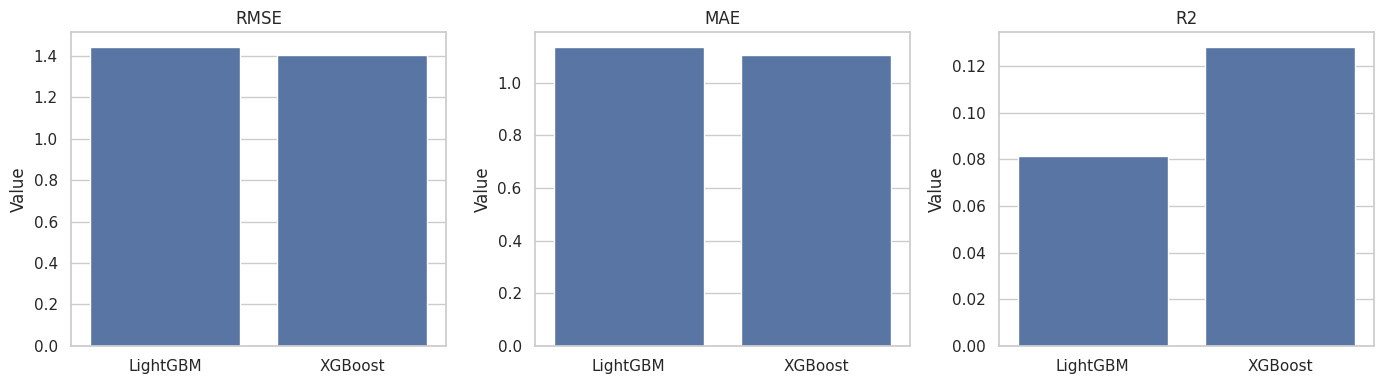

In [7]:
test_metrics_plot = model_metrics.query("split == 'test'").melt(
    id_vars="model",
    value_vars=["rmse", "mae", "r2"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    sns.barplot(data=test_metrics_plot.query("metric == @metric"), x="model", y="value", ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()


The model comparison is a reality check. If the models cannot predict slate outcomes at all, policy targeting will be unreliable. If they predict moderately well, they may still be useful for ranking slates by expected net effect.


### Inspect Feature Importance

This cell extracts feature importance from LightGBM and XGBoost. The goal is to see whether the models are using sensible variables such as treatment assignment, focal position, slate composition, user history, and substitute counts.


In [8]:
importance_rows = []
for model_name, model in trained_models.items():
    importances = getattr(model, "feature_importances_", None)
    if importances is None:
        continue
    temp = pd.DataFrame(
        {
            "model": model_name,
            "feature": X.columns,
            "importance": importances,
        }
    )
    temp = temp.sort_values("importance", ascending=False)
    temp["rank"] = temp.groupby("model")["importance"].rank(method="first", ascending=False)
    importance_rows.append(temp)

feature_importance = pd.concat(importance_rows, ignore_index=True)
top_importance = feature_importance.query("rank <= 15").copy()

display(top_importance)


,model,feature,importance,rank
0,LightGBM,slate_mean_log_popularity_z,539.0000,1.0000
1,LightGBM,log_user_n_ratings,468.0000,2.0000
2,LightGBM,slate_mean_sample_liked_rate,456.0000,3.0000
3,LightGBM,log_focal_sample_rating_count,443.0000,4.0000
4,LightGBM,liked_rate,377.0000,5.0000
5,LightGBM,focal_sample_mean_rating,352.0000,6.0000
6,LightGBM,mean_rating,336.0000,7.0000
7,LightGBM,log_activity_span_days,321.0000,8.0000
8,LightGBM,focal_sample_liked_rate,306.0000,9.0000
9,LightGBM,slate_std_relevance,220.0000,10.0000


Feature importance helps audit the model. Sensible top features suggest the model is learning from pre-promotion slate structure. Treatment assignment and spillover-related features should matter if the model is capturing intervention effects.


#### 9. Plot Top Feature Importance

The table above is dense, so this plot shows the top model features in a compact format. Each model gets its own panel.


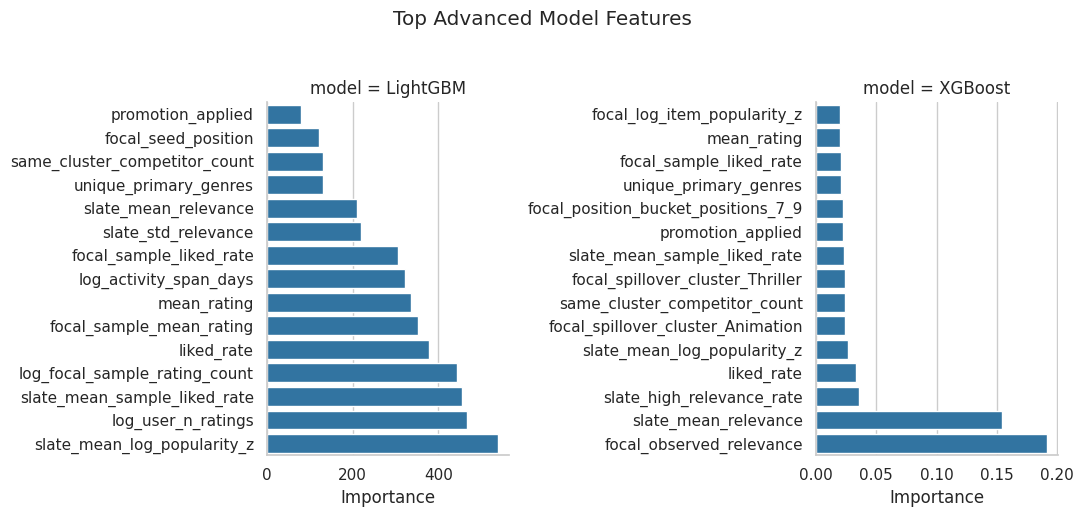

In [9]:
# Plot top feature importance.
g = sns.FacetGrid(
    top_importance,
    col="model",
    sharex=False,
    sharey=False,
    height=5,
    aspect=1.1,
)

def importance_barplot(data, **kwargs):
    """
    Plot model feature importances for the spillover outcome model.
    
    Idea
    ----
    The figure shows which slate, item, and exposure features drive predicted net promotion value in the advanced interference workflow.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    
    Returns
    -------
    matplotlib.axes.Axes
        Axis containing the feature-importance bar plot.
    """
    ordered = data.sort_values("importance", ascending=True)
    ax = plt.gca()
    sns.barplot(data=ordered, x="importance", y="feature", ax=ax, color="tab:blue")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

g.map_dataframe(importance_barplot)
g.fig.suptitle("Top Advanced Model Features", y=1.03)
plt.tight_layout()
plt.show()


The feature plot is useful for communication because it shows which pre-promotion properties drive the model's predictions. If focal position, relevance, and competitor counts appear, the model is aligned with the interference mechanism we care about.


### Generate Counterfactual Predictions

This cell uses each trained outcome model to predict two potential outcomes for every slate:

- predicted total clicks if the focal item is promoted,
- predicted total clicks if the slate is left unchanged.

The difference between those predictions is a model-estimated conditional net effect. Because this is a simulation, we can compare that estimate with the reconstructed true expected promotion lift.


In [10]:
# Generate counterfactual predictions.
def counterfactual_feature_matrix(X_base, treatment_value):
    """
    Create a counterfactual feature matrix with promotion fixed.
    
    Idea
    ----
    The helper copies slate-level model features and sets promotion exposure to treatment or control so model-assisted contrasts can be predicted.
    
    Parameters
    ----------
    X_base : object
        Base feature matrix before counterfactual edits.
    treatment_value : object
        Counterfactual treatment value to assign.
    
    Returns
    -------
    pandas.DataFrame
        Feature matrix under the requested counterfactual promotion state.
    """
    X_cf = X_base.copy()
    X_cf["promotion_applied"] = float(treatment_value)
    return X_cf

counterfactual_predictions = model_table[
    [
        "slate_id",
        "userId",
        "promotion_applied",
        "focal_seed_position",
        "focal_spillover_cluster",
        "total_simulated_clicks",
        "true_promote_lift",
    ]
].copy()

X_promote = counterfactual_feature_matrix(X, 1)
X_control = counterfactual_feature_matrix(X, 0)

counterfactual_summary_rows = []
for model_name, model in trained_models.items():
    pred_promote = model.predict(X_promote)
    pred_control = model.predict(X_control)
    pred_lift = pred_promote - pred_control
    counterfactual_predictions[f"pred_promote_clicks_{model_name}"] = pred_promote
    counterfactual_predictions[f"pred_control_clicks_{model_name}"] = pred_control
    counterfactual_predictions[f"pred_net_lift_{model_name}"] = pred_lift

    counterfactual_summary_rows.append(
        {
            "model": model_name,
            "mean_predicted_lift": pred_lift.mean(),
            "median_predicted_lift": np.median(pred_lift),
            "share_predicted_positive": (pred_lift > 0).mean(),
            "true_mean_lift": counterfactual_predictions["true_promote_lift"].mean(),
            "cate_rmse_vs_oracle": np.sqrt(mean_squared_error(counterfactual_predictions["true_promote_lift"], pred_lift)),
            "cate_mae_vs_oracle": mean_absolute_error(counterfactual_predictions["true_promote_lift"], pred_lift),
            "cate_correlation_vs_oracle": np.corrcoef(counterfactual_predictions["true_promote_lift"], pred_lift)[0, 1],
        }
    )

counterfactual_summary = pd.DataFrame(counterfactual_summary_rows).sort_values("cate_rmse_vs_oracle")
selected_cate_model = counterfactual_summary.iloc[0]["model"]
selected_cate_col = f"pred_net_lift_{selected_cate_model}"

display(counterfactual_summary)
print(f"Selected CATE model by oracle RMSE: {selected_cate_model}")


,model,mean_predicted_lift,median_predicted_lift,share_predicted_positive,true_mean_lift,cate_rmse_vs_oracle,cate_mae_vs_oracle,cate_correlation_vs_oracle
1,XGBoost,-0.2388,-0.2361,0.0100,-0.3158,0.1610,0.1244,0.0189
0,LightGBM,-0.2269,-0.2113,0.1267,-0.3158,0.2481,0.1967,0.0491


Selected CATE model by oracle RMSE: XGBoost


The oracle comparison is only possible because this is a simulation. A good advanced model should at least rank slates in the right direction, even if the exact predicted lift is noisy. The selected model will be used for policy targeting below.


#### 11. Plot Predicted Net Lift Against Oracle Net Lift

This scatter plot shows whether the selected model can identify slates with less harmful or more beneficial promotion effects. The diagonal line represents perfect prediction.


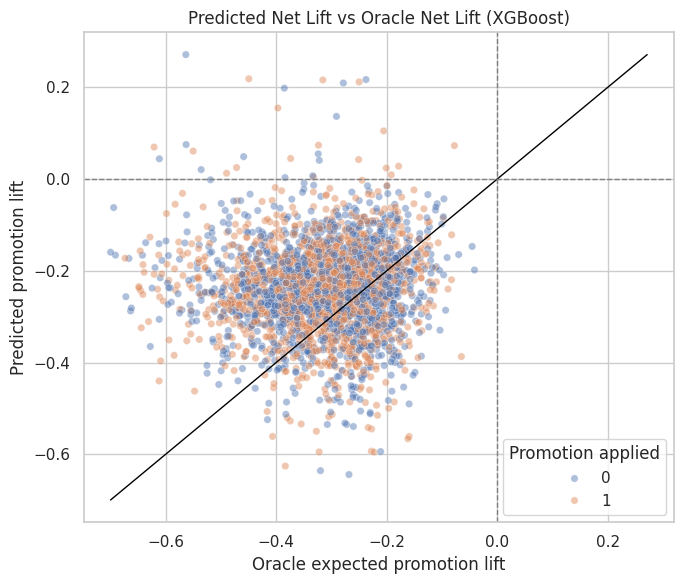

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=counterfactual_predictions,
    x="true_promote_lift",
    y=selected_cate_col,
    hue="promotion_applied",
    alpha=0.45,
    s=28,
    ax=ax,
)
min_value = min(counterfactual_predictions["true_promote_lift"].min(), counterfactual_predictions[selected_cate_col].min())
max_value = max(counterfactual_predictions["true_promote_lift"].max(), counterfactual_predictions[selected_cate_col].max())
ax.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.axvline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title(f"Predicted Net Lift vs Oracle Net Lift ({selected_cate_model})")
ax.set_xlabel("Oracle expected promotion lift")
ax.set_ylabel("Predicted promotion lift")
ax.legend(title="Promotion applied")
plt.tight_layout()
plt.show()


The scatter plot should be read as a targeting diagnostic for prioritizing safer promotions. The key question is whether higher predicted lift corresponds to higher oracle lift. If it does, the model can help prioritize safer promotions.


### Cross-Fitted Model-Assisted AIPW Estimate

Even though assignment is randomized, we can use outcome models to build a model-assisted estimator. This cell fits separate LightGBM outcome models for treated and control slates using cross-fitting, then computes an augmented inverse probability weighted estimate.

The treatment probability is known: promotion was randomized with probability 0.5. Cross-fitting keeps each slate's nuisance predictions out of sample.


In [12]:
# Cross-fitted model-assisted AIPW estimate.
def make_aipw_model(seed):
    """
    Build a model used in the model-assisted AIPW spillover workflow.
    
    Idea
    ----
    The helper configures a learner with a fixed seed so advanced interference estimates can be reproduced and compared across runs.
    
    Parameters
    ----------
    seed : object
        Random seed for reproducible modeling or resampling.
    
    Returns
    -------
    sklearn estimator
        Configured model for nuisance prediction or effect modeling.
    """
    return lgb.LGBMRegressor(
        n_estimators=250,
        learning_rate=0.04,
        num_leaves=15,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=seed,
        verbose=-1,
    )

N_SPLITS = 5
PROPENSITY = 0.5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

m1_hat = np.zeros(len(model_table), dtype=float)
m0_hat = np.zeros(len(model_table), dtype=float)
fold_id = np.zeros(len(model_table), dtype=int)

for fold, (train_positions, holdout_positions) in enumerate(skf.split(X, treatment), start=1):
    X_train_fold = X.iloc[train_positions]
    y_train_fold = y.iloc[train_positions]
    t_train_fold = treatment.iloc[train_positions]

    model_treated = make_aipw_model(RANDOM_SEED + fold)
    model_control = make_aipw_model(RANDOM_SEED + 100 + fold)

    model_treated.fit(X_train_fold.loc[t_train_fold.eq(1)], y_train_fold.loc[t_train_fold.eq(1)])
    model_control.fit(X_train_fold.loc[t_train_fold.eq(0)], y_train_fold.loc[t_train_fold.eq(0)])

    m1_hat[holdout_positions] = model_treated.predict(counterfactual_feature_matrix(X.iloc[holdout_positions], 1))
    m0_hat[holdout_positions] = model_control.predict(counterfactual_feature_matrix(X.iloc[holdout_positions], 0))
    fold_id[holdout_positions] = fold

observed_y = y.to_numpy(dtype=float)
observed_t = treatment.to_numpy(dtype=float)

model_assisted_scores = (
    (m1_hat - m0_hat)
    + observed_t / PROPENSITY * (observed_y - m1_hat)
    - (1 - observed_t) / (1 - PROPENSITY) * (observed_y - m0_hat)
)

simple_difference = observed_y[observed_t == 1].mean() - observed_y[observed_t == 0].mean()
aipw_estimate = model_assisted_scores.mean()
aipw_se = model_assisted_scores.std(ddof=1) / np.sqrt(len(model_assisted_scores))

model_assisted_table = pd.DataFrame(
    [
        {
            "estimator": "Randomized difference in means",
            "estimate": simple_difference,
            "se": np.nan,
            "ci_95_lower": np.nan,
            "ci_95_upper": np.nan,
            "reference": "Observed total simulated clicks",
        },
        {
            "estimator": "Cross-fitted LightGBM AIPW",
            "estimate": aipw_estimate,
            "se": aipw_se,
            "ci_95_lower": aipw_estimate - 1.96 * aipw_se,
            "ci_95_upper": aipw_estimate + 1.96 * aipw_se,
            "reference": "Observed total simulated clicks",
        },
        {
            "estimator": "Oracle mean promotion lift",
            "estimate": model_table["true_promote_lift"].mean(),
            "se": model_table["true_promote_lift"].std(ddof=1) / np.sqrt(len(model_table)),
            "ci_95_lower": model_table["true_promote_lift"].mean() - 1.96 * model_table["true_promote_lift"].std(ddof=1) / np.sqrt(len(model_table)),
            "ci_95_upper": model_table["true_promote_lift"].mean() + 1.96 * model_table["true_promote_lift"].std(ddof=1) / np.sqrt(len(model_table)),
            "reference": "Known simulation lift",
        },
    ]
)

counterfactual_predictions["crossfit_m1_hat"] = m1_hat
counterfactual_predictions["crossfit_m0_hat"] = m0_hat
counterfactual_predictions["crossfit_cate_lgbm"] = m1_hat - m0_hat
counterfactual_predictions["aipw_score"] = model_assisted_scores
counterfactual_predictions["fold_id"] = fold_id

display(model_assisted_table)


,estimator,estimate,se,ci_95_lower,ci_95_upper,reference
0,Randomized difference in means,-0.3078,NaN,NaN,NaN,Observed total simulated clicks
1,Cross-fitted LightGBM AIPW,-0.3036,0.0505,-0.4024,-0.2047,Observed total simulated clicks
2,Oracle mean promotion lift,-0.3158,0.0019,-0.3195,-0.3120,Known simulation lift


The AIPW estimator is a robustness check. Because the design is randomized, the simple difference-in-means is already valid. The model-assisted estimate asks whether flexible outcome models produce a similar average answer while also generating useful conditional-effect predictions.


### Model-Targeted Promotion Policies

This cell compares several targeting rules using the selected model's predicted net lift. Since this is a simulation, the policies are evaluated using oracle expected promotion lift. In a real setting, this would require an online experiment or a valid off-policy evaluation design.

The table reports both value per selected slate and value per 1,000 eligible slates. The second metric accounts for how many slates the policy chooses to promote.


In [13]:
# Model-Targeted promotion policies.
policy_scores = counterfactual_predictions.copy()
policy_scores["selected_model_predicted_lift"] = policy_scores[selected_cate_col]

predicted_lift = policy_scores["selected_model_predicted_lift"]
true_lift = policy_scores["true_promote_lift"]

policy_masks = {
    "Promote all eligible slates": np.ones(len(policy_scores), dtype=bool),
    "Promote top 50% by predicted net lift": predicted_lift >= predicted_lift.quantile(0.50),
    "Promote top 25% by predicted net lift": predicted_lift >= predicted_lift.quantile(0.75),
    "Promote only predicted-positive slates": predicted_lift > 0,
    "Oracle top 25% benchmark": true_lift >= true_lift.quantile(0.75),
}

policy_rows = []
for policy_name, mask in policy_masks.items():
    mask = np.asarray(mask, dtype=bool)
    selected_count = int(mask.sum())
    coverage = selected_count / len(policy_scores)
    if selected_count == 0:
        mean_predicted_selected = np.nan
        mean_true_selected = np.nan
        lift_per_1000_selected = np.nan
        lift_per_1000_eligible = 0.0
    else:
        mean_predicted_selected = predicted_lift[mask].mean()
        mean_true_selected = true_lift[mask].mean()
        lift_per_1000_selected = mean_true_selected * 1000
        lift_per_1000_eligible = true_lift[mask].sum() / len(policy_scores) * 1000
    policy_rows.append(
        {
            "policy": policy_name,
            "selected_slates": selected_count,
            "coverage": coverage,
            "mean_predicted_lift_selected": mean_predicted_selected,
            "mean_oracle_lift_selected": mean_true_selected,
            "oracle_lift_per_1000_selected_slates": lift_per_1000_selected,
            "oracle_lift_per_1000_eligible_slates": lift_per_1000_eligible,
        }
    )

policy_targeting = pd.DataFrame(policy_rows)

display(policy_targeting)


,policy,selected_slates,coverage,mean_predicted_lift_selected,mean_oracle_lift_selected,oracle_lift_per_1000_selected_slates,oracle_lift_per_1000_eligible_slates
0,Promote all eligible slates,3000,1.0000,-0.2388,-0.3158,-315.7549,-315.7549
1,Promote top 50% by predicted net lift,1500,0.5000,-0.1648,-0.3091,-309.0693,-154.5346
2,Promote top 25% by predicted net lift,750,0.2500,-0.1213,-0.3065,-306.4754,-76.6188
3,Promote only predicted-positive slates,30,0.0100,0.0901,-0.3654,-365.3709,-3.6537
4,Oracle top 25% benchmark,750,0.2500,-0.2284,-0.1953,-195.3376,-48.8344


The targeting table shows whether the model can reduce harm by avoiding slates with strongly negative predicted net lift. The oracle benchmark shows the value available if targeting were perfect.


#### 14. Plot Policy Targeting Results

This plot compares the net oracle value of each promotion rule. The value is shown per 1,000 eligible slates, so policies that promote fewer slates are penalized for lower coverage.


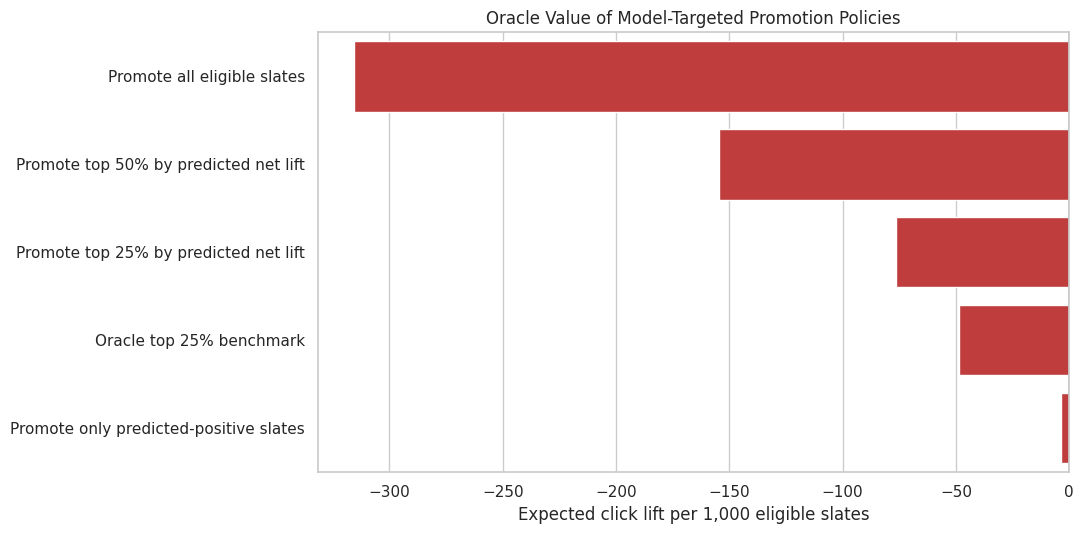

In [14]:
policy_plot = policy_targeting.sort_values("oracle_lift_per_1000_eligible_slates", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["tab:green" if value >= 0 else "tab:red" for value in policy_plot["oracle_lift_per_1000_eligible_slates"]]
sns.barplot(
    data=policy_plot,
    x="oracle_lift_per_1000_eligible_slates",
    y="policy",
    hue="policy",
    palette=dict(zip(policy_plot["policy"], colors)),
    legend=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Oracle Value of Model-Targeted Promotion Policies")
ax.set_xlabel("Expected click lift per 1,000 eligible slates")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The policy plot translates advanced modeling into a decision question. If targeted rules are less negative than promoting all slates, the model is useful for reducing harm. The safest policy may still be to avoid promotion unless predicted net value is positive.


### Heterogeneity Diagnostics

This cell summarizes true and predicted net lift across interpretable segments: focal starting position, substitute count, displaced count, user activity, and focal cluster. The goal is to connect ML predictions back to product reasoning.


In [15]:
# Heterogeneity diagnostics.
heterogeneity_frame = model_table[
    [
        "slate_id",
        "focal_seed_position",
        "focal_position_bucket",
        "focal_spillover_cluster",
        "same_cluster_competitor_count",
        "displaced_candidate_count",
        "n_ratings",
        "true_promote_lift",
    ]
].merge(
    policy_scores[["slate_id", "selected_model_predicted_lift"]],
    on="slate_id",
    how="left",
)

heterogeneity_frame["same_cluster_count_bucket"] = pd.cut(
    heterogeneity_frame["same_cluster_competitor_count"],
    bins=[-0.1, 0, 2, 5, 11],
    labels=["0", "1-2", "3-5", "6+"],
)
heterogeneity_frame["displaced_count_bucket"] = pd.cut(
    heterogeneity_frame["displaced_candidate_count"],
    bins=[-0.1, 4, 7, 11],
    labels=["4_or_fewer", "5-7", "8+"],
)
heterogeneity_frame["user_activity_bucket"] = pd.qcut(
    heterogeneity_frame["n_ratings"].rank(method="first"),
    q=4,
    labels=["lowest_activity", "low_mid_activity", "high_mid_activity", "highest_activity"],
)

def summarize_segment(frame, segment_type, segment_column, min_slates=30):
    """
    Summarize predicted net lift within an interference segment.
    
    Idea
    ----
    The helper aggregates model-predicted treatment contrasts by item, genre, position, or slate segment to identify safer promotion regions.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    segment_type : object
        Label describing the segment family.
    segment_column : object
        Column defining the segment to summarize.
    min_slates : object
        Minimum slates required to keep a segment.
    
    Returns
    -------
    dict
        Segment summary with counts and average predicted net lift.
    """
    summary = (
        frame.groupby(segment_column, observed=True)
        .agg(
            slates=("slate_id", "size"),
            mean_true_lift=("true_promote_lift", "mean"),
            mean_predicted_lift=("selected_model_predicted_lift", "mean"),
            share_positive_true_lift=("true_promote_lift", lambda s: (s > 0).mean()),
        )
        .reset_index()
        .rename(columns={segment_column: "segment"})
    )
    summary = summary.query("slates >= @min_slates").copy()
    summary["segment_type"] = segment_type
    return summary

heterogeneity_summaries = pd.concat(
    [
        summarize_segment(heterogeneity_frame, "focal_position_bucket", "focal_position_bucket"),
        summarize_segment(heterogeneity_frame, "same_cluster_count_bucket", "same_cluster_count_bucket"),
        summarize_segment(heterogeneity_frame, "displaced_count_bucket", "displaced_count_bucket"),
        summarize_segment(heterogeneity_frame, "user_activity_bucket", "user_activity_bucket"),
        summarize_segment(heterogeneity_frame, "focal_cluster", "focal_spillover_cluster", min_slates=60),
    ],
    ignore_index=True,
)
heterogeneity_summaries = heterogeneity_summaries.sort_values(["segment_type", "mean_true_lift"])

display(heterogeneity_summaries)


,segment,slates,mean_true_lift,mean_predicted_lift,share_positive_true_lift,segment_type
9,8+,1472,-0.3478,-0.2735,0.0000,displaced_count_bucket
8,5-7,1162,-0.2961,-0.2121,0.0000,displaced_count_bucket
7,4_or_fewer,366,-0.2493,-0.1842,0.0000,displaced_count_bucket
14,Action,799,-0.3625,-0.2154,0.0000,focal_cluster
17,Comedy,658,-0.3258,-0.2348,0.0000,focal_cluster
19,Drama,636,-0.3221,-0.2426,0.0000,focal_cluster
15,Adventure,318,-0.2784,-0.2439,0.0000,focal_cluster
18,Crime,253,-0.2725,-0.2623,0.0000,focal_cluster
16,Animation,70,-0.2496,-0.2290,0.0000,focal_cluster
20,Horror,65,-0.2378,-0.2969,0.0000,focal_cluster


The heterogeneity table makes the targeting story interpretable. Segments with less negative or positive true lift are safer promotion candidates. Segments with many substitutes or large displacement exposure are more likely to show negative net effects.


#### 16. Plot Interpretable Heterogeneity

This plot focuses on the most actionable segment types: focal starting position and same-cluster competitor count. These are directly tied to the mechanism of item competition.


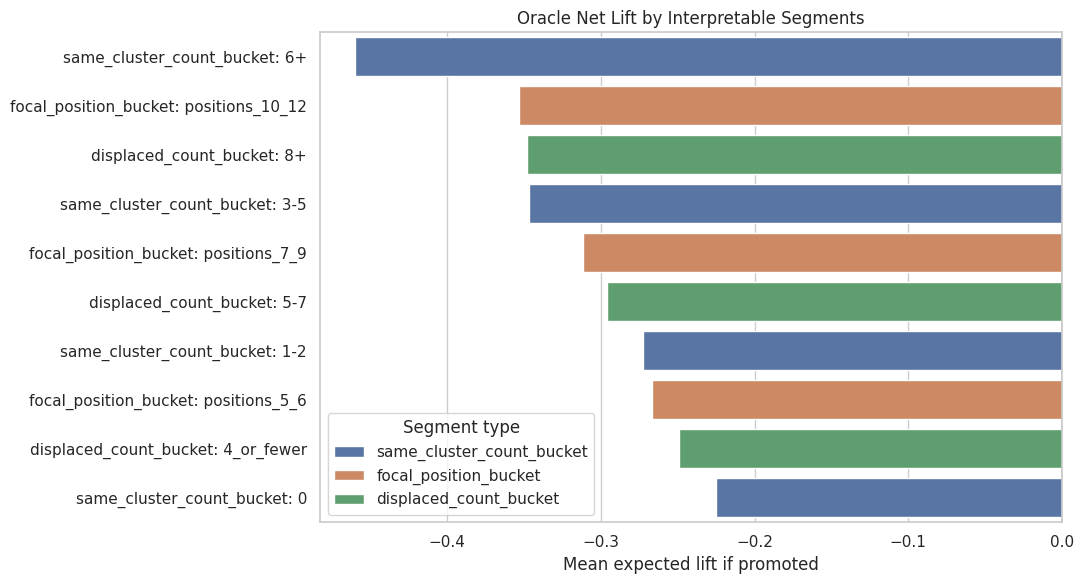

In [16]:
heterogeneity_plot = heterogeneity_summaries.query(
    "segment_type in ['focal_position_bucket', 'same_cluster_count_bucket', 'displaced_count_bucket']"
).copy()
heterogeneity_plot["segment_label"] = heterogeneity_plot["segment_type"] + ": " + heterogeneity_plot["segment"].astype(str)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=heterogeneity_plot.sort_values("mean_true_lift"),
    x="mean_true_lift",
    y="segment_label",
    hue="segment_type",
    dodge=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Oracle Net Lift by Interpretable Segments")
ax.set_xlabel("Mean expected lift if promoted")
ax.set_ylabel("")
ax.legend(title="Segment type")
plt.tight_layout()
plt.show()


The segment plot connects advanced modeling back to recommendation design. If promotions are most harmful in slates with many displaced or same-cluster competitors, then safer policies should account for local slate competition before promoting an item.


### Advanced Modeling Takeaways Table

This cell creates a compact summary table showing what the advanced models added beyond the transparent randomized estimators.


In [17]:
# Advanced modeling takeaways table.
best_metrics = model_metrics.query("split == 'test' and model == @best_model_name").iloc[0]
best_counterfactual = counterfactual_summary.query("model == @selected_cate_model").iloc[0]
best_policy = policy_targeting.sort_values("oracle_lift_per_1000_eligible_slates", ascending=False).iloc[0]

advanced_takeaways = pd.DataFrame(
    [
        {
            "area": "Outcome modeling",
            "finding": f"{best_model_name} had the best held-out RMSE at {best_metrics['rmse']:.3f} clicks per slate.",
            "why_it_matters": "Flexible models can summarize how slate composition and treatment assignment relate to total outcomes.",
        },
        {
            "area": "Conditional effects",
            "finding": f"{selected_cate_model} had CATE RMSE {best_counterfactual['cate_rmse_vs_oracle']:.3f} versus the oracle simulation lift.",
            "why_it_matters": "The model can be used to rank slates by predicted net harm or benefit, with simulation validation.",
        },
        {
            "area": "Model-assisted estimation",
            "finding": f"Cross-fitted AIPW estimated {aipw_estimate:.3f} total clicks per slate, compared with {simple_difference:.3f} from the randomized difference-in-means.",
            "why_it_matters": "Model-assisted estimates should agree with the randomized baseline before being used for targeting.",
        },
        {
            "area": "Policy targeting",
            "finding": f"The best evaluated policy was '{best_policy['policy']}' with {best_policy['oracle_lift_per_1000_eligible_slates']:.1f} oracle lift per 1,000 eligible slates.",
            "why_it_matters": "Targeting can reduce displacement harm compared with promoting every eligible slate.",
        },
    ]
)

display(advanced_takeaways)


,area,finding,why_it_matters
0,Outcome modeling,XGBoost had the best held-out RMSE at 1.405 cl...,Flexible models can summarize how slate compos...
1,Conditional effects,XGBoost had CATE RMSE 0.161 versus the oracle ...,The model can be used to rank slates by predic...
2,Model-assisted estimation,Cross-fitted AIPW estimated -0.304 total click...,Model-assisted estimates should agree with the...
3,Policy targeting,The best evaluated policy was 'Promote only pr...,Targeting can reduce displacement harm compare...


This table keeps the advanced work concrete: model performance, conditional-effect validation, model-assisted estimation, and policy targeting. This matters because the causal estimate is built from these supporting predictions, so weak nuisance behavior should make the downstream effect estimate less persuasive.


In [ ]:
#| include: false
# Save advanced modeling outputs.
MODEL_METRICS_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_model_metrics.csv"
FEATURE_IMPORTANCE_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_feature_importance.csv"
COUNTERFACTUAL_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_counterfactual_predictions.parquet"
COUNTERFACTUAL_SUMMARY_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_counterfactual_summary.csv"
AIPW_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_aipw_estimates.csv"
POLICY_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_policy_targeting.csv"
HETEROGENEITY_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_heterogeneity.csv"
TAKEAWAYS_OUTPUT = PROCESSED_DIR / "movielens_interference_advanced_takeaways.csv"

model_metrics.to_csv(MODEL_METRICS_OUTPUT, index=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_OUTPUT, index=False)
counterfactual_predictions.to_parquet(COUNTERFACTUAL_OUTPUT, index=False)
counterfactual_summary.to_csv(COUNTERFACTUAL_SUMMARY_OUTPUT, index=False)
model_assisted_table.to_csv(AIPW_OUTPUT, index=False)
policy_targeting.to_csv(POLICY_OUTPUT, index=False)
heterogeneity_summaries.to_csv(HETEROGENEITY_OUTPUT, index=False)
advanced_takeaways.to_csv(TAKEAWAYS_OUTPUT, index=False)


The saved files complete the advanced-modeling handoff. The key artifacts are the counterfactual predictions, AIPW estimate table, policy targeting table, and advanced takeaways. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


### Takeaways and Next Step

This notebook added advanced modeling without changing the causal foundation:

- LightGBM and XGBoost were trained to predict total slate outcomes from pre-promotion features and treatment assignment.
- Counterfactual predictions estimated conditional net promotion effects for each slate.
- A cross-fitted model-assisted AIPW estimate was compared with the simple randomized estimator.
- Targeted promotion rules were evaluated against the oracle simulation lift.
- Heterogeneity summaries showed where promotion is most likely to be safer or more harmful.

The lab now has a complete workflow covering dataset setup, exposure mapping, randomized estimators, direct/indirect/total decomposition, advanced models, assumptions, limitations, figures, tables, and decision-oriented interpretation.
